# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
import time
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_lengths = (1, 6)
seq_chars = string.ascii_uppercase
instruction_set_len = len(seq_chars)
total_size = sum(instruction_set_len ** n for n in seq_lengths)
print(f'{total_size:=,} of {instruction_set_len:=} instructions at {seq_lengths=}')

seq_products = itertools.chain(
    *(itertools.product(string.ascii_uppercase, repeat=n)
      for n in seq_lengths)
)
filter_seq_products = (
    f'{i:08d}-' + ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3, 5)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 2 ** 16 - 1)
filter_seq_products = itertools.islice(filter_seq_products, None, 6000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
            time.sleep(0.1)
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

308,915,802 of 26 instructions at seq_lengths=(1, 6)
00000000-A 00104035-AAFXWJ 00195804-AALDPY 00286994-AAQING 00378185-AAVNKP 00469956-ABATEG 00633575-ABKBFH 
00822751-ABUVBH 00972864-ACDJCW 01162065-ACOCZV 01352525-ACYYTF 01502299-ADHMHT 01691461-ADSGDF 01862649-AEBZJJ 
02031781-AELPOL 02220894-AEWJIA 02382548-AFFOLM 02561207-AFPSSZ 02747047-AGAHQR 02901502-AGJCDG 03090702-AGTWAE 
03259750-AHDMCA 03430934-AHNFIA 03620136-AHXZFA 03789206-AIHPHS 03960211-AIRIGV 04130522-AJBAFG 04299665-AJKQKT 
04488832-AJVKGK 04658992-AKFBZA 04829150-AKOTRO 05018260-AKZNLA 05188409-ALJFDF 05358593-ALSWWT 05527683-AMCNAF 
05706293-AMMRFV 05888030-AMXABS 06057116-ANGQFA 06228360-ANQJNI 06407078-AOANXC 06586571-AOKTKR 06757810-AOUMSU 
06926844-APECUC 07116004-APOWPM 07286870-APYPJG 07456319-AQIGAN 07626519-AQRXUR 07796663-ARBPMR 07985779-ARMJGJ 
08155539-ARWAJP 08325849-ASFSHZ 08515247-ASQMMN 08684193-ATACKL 08854482-ATJUIA 09030062-ATTUBC 09194520-AUDDIK 
09383936-AUNXNQ 09555179-AUXQVX 09724214-AVHGXG 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

37

In [4]:
reports_paths.sort_values(ascending=False).head()

8     data/cash_app_report_1790376319643.csv
17    data/cash_app_report_1789218958509.csv
7     data/cash_app_report_1788300495785.csv
35    data/cash_app_report_1787932141636.csv
33    data/cash_app_report_1787843145215.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1790376319643.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.28,$0.00,$0.28,VONV,NaN,NaN,COMPLETE,$0.28 Dividend from Vanguard Russell 1000 Valu...,NaN,Cash Balance
1,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,FIS,NaN,NaN,COMPLETE,$0.11 Dividend from Fidelity National Information,NaN,Cash Balance
2,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.14,$0.00,$0.14,PYPL,NaN,NaN,COMPLETE,$0.14 Dividend from PayPal,NaN,Cash Balance
3,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.06,$0.00,$0.06,VCR,NaN,NaN,COMPLETE,$0.06 Dividend from Vanguard Consumer Discreti...,NaN,Cash Balance
4,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.27,$0.00,$0.27,VDE,NaN,NaN,COMPLETE,$0.27 Dividend from Energy ETF Vanguard,NaN,Cash Balance
5,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,VDC,NaN,NaN,COMPLETE,$0.11 Dividend from Vanguard Consumer Staples ...,NaN,Cash Balance
6,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.02,$0.00,$0.02,VONG,NaN,NaN,COMPLETE,$0.02 Dividend from Vanguard Russell 1000 Grow...,NaN,Cash Balance
7,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.06,$0.00,$0.06,LMT,NaN,NaN,COMPLETE,$0.06 Dividend from Lockheed Martin,NaN,Cash Balance
8,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.16,$0.00,$0.16,VFH,NaN,NaN,COMPLETE,$0.16 Dividend from Vanguard Financials ETF,NaN,Cash Balance
9,2026-09-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.16,$0.00,$0.16,KHC,NaN,NaN,COMPLETE,$0.16 Dividend from Kraft Heinz,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
885,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
886,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
887,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
888,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
889,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(890, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
483,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
267,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
354,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
239,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
268,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
352,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
318,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
418,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
272,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
184,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,649.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
466,2026-06-10 13:30:34+00:00,-10.00,-10.00,105.78,0.09453,0.0,UPS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of United Parcel Service,NaN
447,2026-06-15 13:30:28+00:00,-10.00,-10.00,127.25,0.07858,0.0,VONG,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Russell 1000 Growth ETF,NaN
424,2026-06-16 13:30:08+00:00,-5.00,-5.00,57.42,0.08707,0.0,TSN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Tyson Foods,NaN
342,2026-06-22 13:30:01+00:00,5.00,5.00,64.00,0.07812,0.0,MRNA,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$5 Sale of Moderna,NaN
170,2026-07-16 13:30:04+00:00,-10.00,-10.00,116.54,0.08580,0.0,UAL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of United Continental Holdings,NaN
143,2026-07-20 13:30:06+00:00,-10.00,-10.00,58.53,0.17085,0.0,KR,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Kroger,NaN
123,2026-07-29 13:30:01+00:00,-10.00,-10.00,58.06,0.17223,0.0,VGSH,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Short-Term Treasury ETF,NaN
85,2026-08-27 17:22:57+00:00,-10.00,-10.00,53.40,0.18727,0.0,VGLT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Long-Treasury ETF,NaN
9,2026-09-25 04:00:00+00:00,0.16,0.16,NaN,0.00000,0.0,KHC,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.16 Dividend from Kraft Heinz,NaN
8,2026-09-25 04:00:00+00:00,0.16,0.16,NaN,0.00000,0.0,VFH,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.16 Dividend from Vanguard Financials ETF,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
204,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
883,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
884,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
885,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
887,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
888,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
889,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


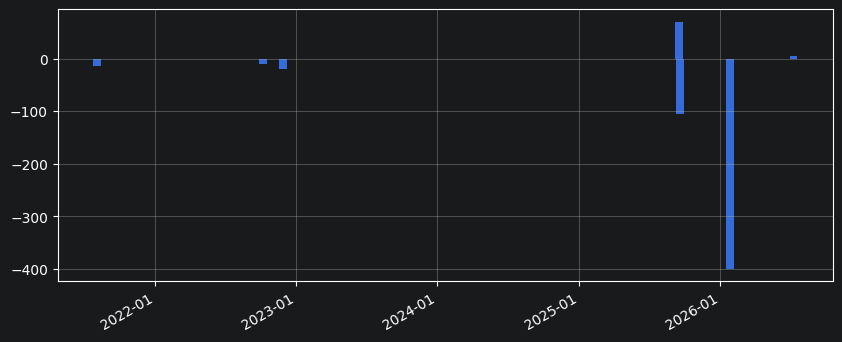

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,890.00,890.00,649.00,890.00,887.00
mean,-0.01,-0.00,3791.58,0.12,-0.01
std,34.42,34.41,15403.21,0.30,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.05,0.00,0.00
50%,-10.00,-10.00,128.29,0.04,0.00
75%,0.07,0.07,299.92,0.12,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

date            669
asset_price     636
asset_amount    633
notes           516
asset_type      190
amount           80
net_amount       79
trans_type       11
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    565
Stock Dividends              142
Deposits                      74
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,565,10.35,1.00,10.00,10.00,10.00,50.00
Stock Dividends,142,0.14,0.01,0.05,0.11,0.17,0.95
Deposits,74,88.46,1.00,62.50,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      17
JPM      15
ORCL     14
WFC      13
AMZN     13
META     13
MCD      12
VGLT     11
V        11
VONV     10
GOOGL    10
DOW      10
VMBS     10
DELL     10
NFLX     10
PZZA     10
GOOG      9
MSFT      9
VOO       8
UBER      8
PYPL      7
VFH       7
WMT       7
TGT       7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

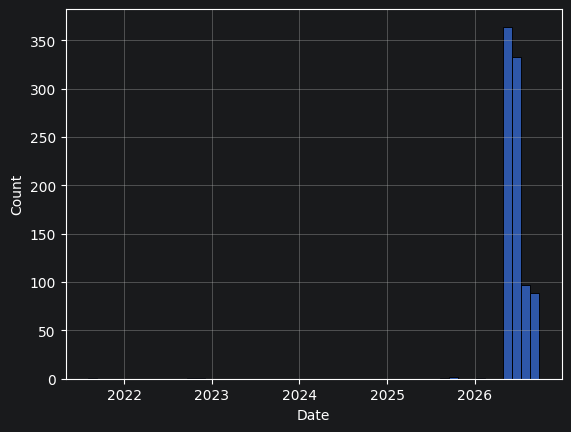

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-26,2026-05-27,2026-05-30,2026-06-03,2026-06-15,2026-07-06,2026-08-17,2026-09-03,2026-09-25


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,17,-211.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,15,-89.64,"(-25.0, -10.0, -5.0, 0.36, 10.0, 20.0)",6
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
WFC,13,-55.64,"(-25.0, -10.0, -5.0, -1.0, 0.36, 10.0, 20.0)",7
META,13,-95.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,13,-231.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,12,-109.06,"(-25.0, -10.0, -5.0, 0.2, 0.74)",5
VGLT,11,-99.22,"(-25.0, -20.0, -10.0, -5.0, 0.06, 0.32, 0.4)",7


In [22]:
data['currency'].value_counts()

currency
USD    890
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    565
Stock Dividends              142
Deposits                      74
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Investing,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,,
total,24,10,2,565,142,50,793
BTC,24,10,0,0,0,0,34
XYZ,0,0,0,16,0,1,17
JPM,0,0,0,12,1,2,15
ORCL,0,0,0,13,1,0,14
AMZN,0,0,0,13,0,0,13
WFC,0,0,0,10,1,2,13
META,0,0,0,12,1,0,13
MCD,0,0,0,10,2,0,12


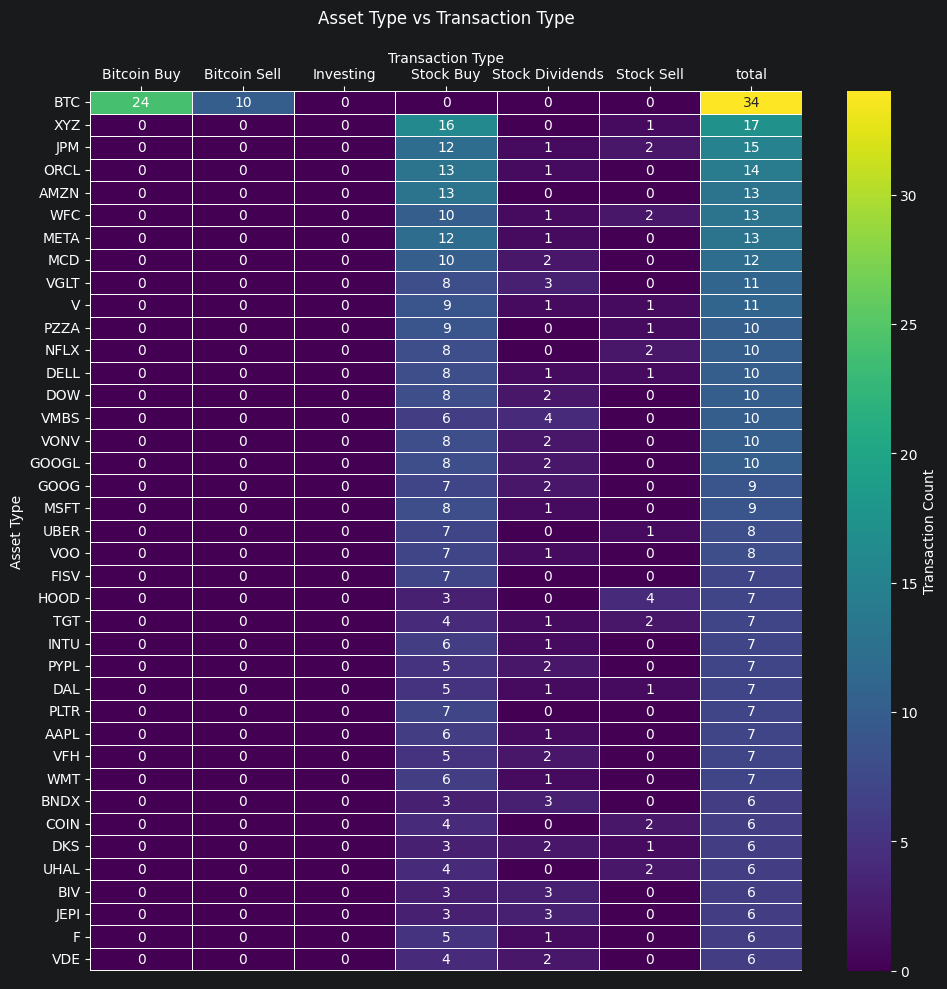

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
162,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
186,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
192,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
213,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
225,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


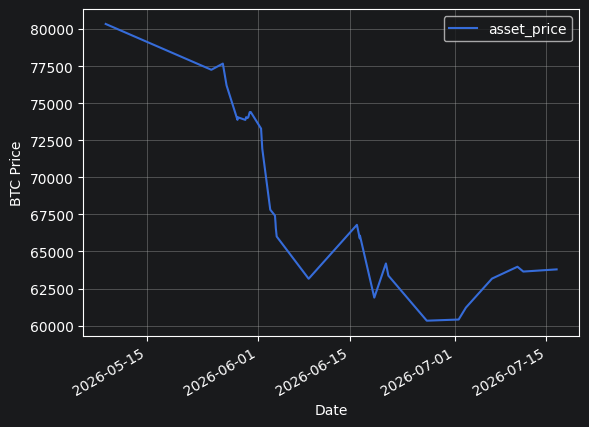

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

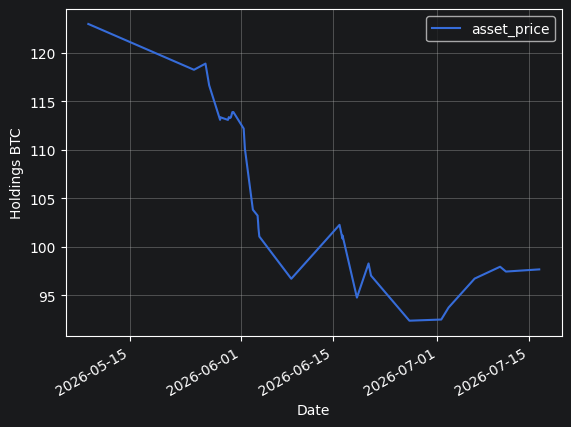

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

162     8.999780
186     9.999987
192     9.999926
213     9.999928
225    20.000229
253     9.800290
290     4.900090
345    10.000046
347     4.899747
356    19.999846
438     5.000156
439     4.999899
442     4.900240
478    19.999798
558     9.799846
585     9.800287
609     0.980144
706     9.800221
717     0.979969
734     9.799652
792     4.900136
794     9.799865
797     4.900112
798     9.799903
802     9.799965
806    24.500200
813    24.499951
817    24.500084
836     9.799731
840     9.800031
863    24.499991
880     9.799898
881     4.900356
882     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
49,2026-09-02 13:30:03+00:00,-10.0,-10.0,77.30,0.12936,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
133,2026-07-27 13:30:03+00:00,-10.0,-10.0,78.88,0.12677,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
141,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
208,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
289,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
318,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
400,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
445,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
493,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
569,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


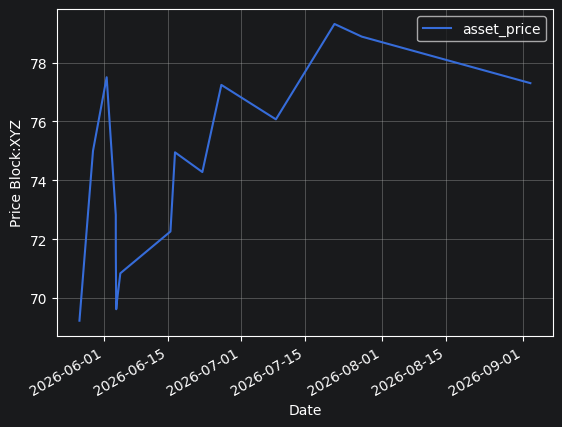

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     17
JPM     15
ORCL    14
WFC     13
        ..
RTX      1
SG       1
SHOP     1
SLAB     1
ZG       1
Name: amount, Length: 190, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    890.000000
mean       0.124870
std        0.302190
min        0.000000
25%        0.000000
50%        0.036455
75%        0.124252
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
282,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
355,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
619,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
744,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 13:30:15+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000e+00,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.95337,0.000000,0.000000
2026-06-03 13:48:39+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,31.527923,9.686363,19.992722,0.0,99.663815,0.000000,9.95337,0.000000,0.000000
2026-06-03 19:32:54+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,51.890247,18.724670,27.762524,0.0,131.892037,19.945984,9.95337,0.000000,0.000000
2026-06-03 19:38:51+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.95337,0.000000,0.000000
2026-06-04 13:30:18+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.95337,9.999727,9.999925
2026-06-18 17:09:55+00:00,28.691891,9.999493,0.000000,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,0.000000,27.762524,0.0,174.501547,30.191289,9.95337,9.999727,9.999925
2026-06-18 17:13:02+00:00,28.691891,9.999493,0.000000,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,0.000000,27.762524,0.0,174.501547,30.191289,9.95337,9.999727,9.999925
2026-07-10 13:30:11+00:00,0.000000,9.999493,0.000000,8.379889,0.000000,9.999577,0.000000,0.000000,0.000000,30.069556,...,6.113515e+00,58.199610,0.000000,0.000000,0.0,196.334284,0.000000,0.00000,9.999727,9.999925
2026-07-27 13:30:17+00:00,0.000000,9.999493,0.000000,18.377823,0.000000,9.999577,0.000000,0.000000,0.000000,30.069556,...,-8.337775e-16,0.000000,0.000000,0.000000,0.0,210.903774,0.000000,0.00000,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(2364.5406303000004)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    241.595026
XYZ     220.903302
JPM     104.538330
UBER     96.165081
META     90.825274
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
GM     0.000000e+00
GIS    0.000000e+00
MCD    0.000000e+00
WEN   -8.337775e-16
BTC             NaN
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['AAPL', 'ACN', 'ADP', 'ALKT', 'ALLY', 'AMAT', 'AMX', 'ASML', 'AVGO',
       'BBEU',
       ...
       'VRSN', 'VSS', 'VTEB', 'VZ', 'WFC', 'WMG', 'WMT', 'XLB', 'YUM', 'YUMC'],
      dtype='str', name='asset_type', length=107)

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
476,AAPL,$10 Purchase of Apple
214,AAPL,$10 Purchase of Apple
97,AAPL,$0.05 Dividend from Apple
685,AAPL,$10 Purchase of Apple
729,AAPL,$10 Purchase of Apple
...,...,...
248,YUM,$10 Purchase of Yum! Brands
602,YUM,$20 Purchase of Yum! Brands
22,YUMC,$0.14 Dividend from Yum China
350,YUMC,$10 Purchase of Yum China


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-31 13:30:06+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:13+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:16+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:17+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-09-02 13:30:03+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.093423,0.0,0.0,0.004229,0.004229


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.890000e+02
mean     5.291005e-03
std      1.232233e-02
min     -3.526171e-19
25%      0.000000e+00
50%      0.000000e+00
75%      6.535955e-03
max      1.021742e-01
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.102174
XYZ     0.093423
JPM     0.044211
UBER    0.040670
META    0.038411
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
GM     0.000000e+00
GIS    0.000000e+00
MCD    0.000000e+00
WEN   -3.526171e-19
BTC             NaN
Name: 2026-09-02 13:30:03+00:00, dtype: float64

<Axes: ylabel='Frequency'>

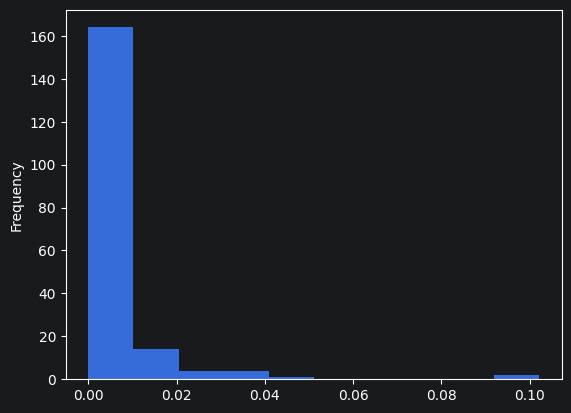

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-31 13:30:06+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:13+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:16+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-08-31 13:30:17+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.089194,0.0,0.0,0.004229,0.004229
2026-09-02 13:30:03+00:00,0.0,0.004229,0.0,0.007772,0.0,0.004229,0.0,0.0,0.0,0.012717,...,-3.526171e-19,0.0,0.0,0.0,0.0,0.093423,0.0,0.0,0.004229,0.004229


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-08 16:33:33+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:15+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-28 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:39:17+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,543.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:15:27+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:50:14+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,69.62,NaN,NaN,NaN,NaN
2026-06-22 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 16:52:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-08 16:33:33+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-07-10 13:30:15+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-08-28 13:30:21+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.139390,1.075766,0.995338,1.0,1.0
2026-06-03 19:39:17+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-07-01 13:30:23+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-18 17:15:27+00:00,1.018386,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-03 15:50:14+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.005633,1.000000,1.000000,1.0,1.0
2026-06-22 13:30:01+00:00,1.018386,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0
2026-06-02 16:52:54+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

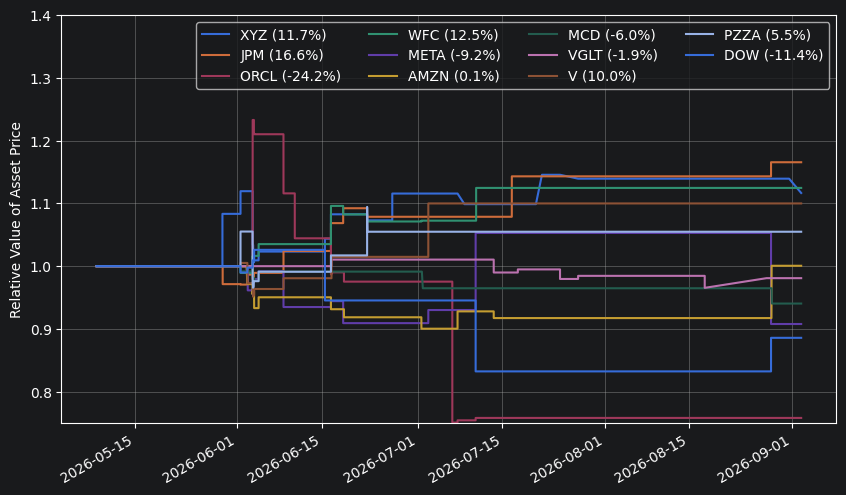

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-08-31 13:30:06+00:00    1.139390
2026-08-31 13:30:13+00:00    1.139390
2026-08-31 13:30:16+00:00    1.139390
2026-08-31 13:30:17+00:00    1.139390
2026-09-02 13:30:03+00:00    1.116568
Name: XYZ, Length: 517, dtype: float64

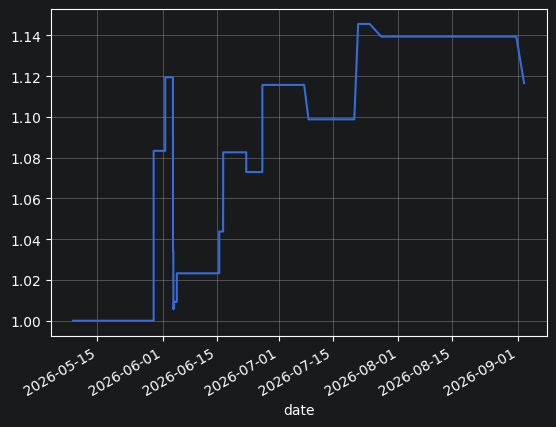

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data
    .sort_values('date', ascending=False)
    .assign(asset_price=lambda x: x['asset_price'].ffill())
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    [data['trans_type'] == 'Stock Dividends']
    .drop(columns=['fee', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

/var/folders/ll/02466vfd3qb7kfp5yfm5wx340000gn/T/ipykernel_80578/2296917298.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data


,date,amount,asset_price,asset_amount,asset_type,notes,stock_direction
0,2026-09-25,0.28,NaN,0.0,VONV,$0.28 Dividend from Vanguard Russell 1000 Valu...,NaN
8,2026-09-25,0.16,NaN,0.0,VFH,$0.16 Dividend from Vanguard Financials ETF,NaN
14,2026-09-25,0.11,NaN,0.0,VHT,$0.11 Dividend from Vanguard Health Care ETF,NaN
13,2026-09-25,0.03,NaN,0.0,VGT,$0.03 Dividend from Vanguard Information Techn...,NaN
12,2026-09-25,0.12,NaN,0.0,DKS,$0.12 Dividend from Dick's Sporting Goods,NaN
...,...,...,...,...,...,...,...
440,2026-06-16,0.20,65883.50,0.0,MCD,$0.20 Dividend from McDonald's,NaN
459,2026-06-15,0.02,490.50,0.0,GOOGL,$0.02 Dividend from Alphabet Inc. Class A,NaN
458,2026-06-15,0.02,490.50,0.0,GOOG,$0.02 Dividend from Alphabet Inc. Class C,NaN
462,2026-06-12,0.05,490.50,0.0,DOW,$0.05 Dividend from Dow,NaN


In [60]:
div_data['amount'].sum()

np.float64(19.259999999999998)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_price,asset_amount,asset_type,notes,stock_direction
32,2026-09-11,0.95,NaN,0.0,DOW,$0.95 Dividend from Dow,NaN
25,2026-09-16,0.74,NaN,0.0,MCD,$0.74 Dividend from McDonald's,NaN
17,2026-09-23,0.66,NaN,0.0,IEP,$0.66 Dividend from Icahn Enterprises,NaN
116,2026-08-03,0.48,712.39,0.0,T,$0.48 Dividend from AT&T,NaN
47,2026-09-03,0.40,NaN,0.0,VGLT,$0.40 Dividend from Vanguard Long-Treasury ETF,NaN
...,...,...,...,...,...,...,...
36,2026-09-10,0.01,NaN,0.0,H,$0.01 Dividend from Hyatt Hotels Corporation,NaN
177,2026-07-15,0.01,78.98,0.0,TMO,$0.01 Dividend from Thermo Fisher Scientific,NaN
309,2026-06-23,0.01,6.28,0.0,VONG,$0.01 Dividend from Vanguard Russell 1000 Grow...,NaN
298,2026-06-26,0.01,60331.07,0.0,NVDA,$0.01 Dividend from NVIDIA,NaN


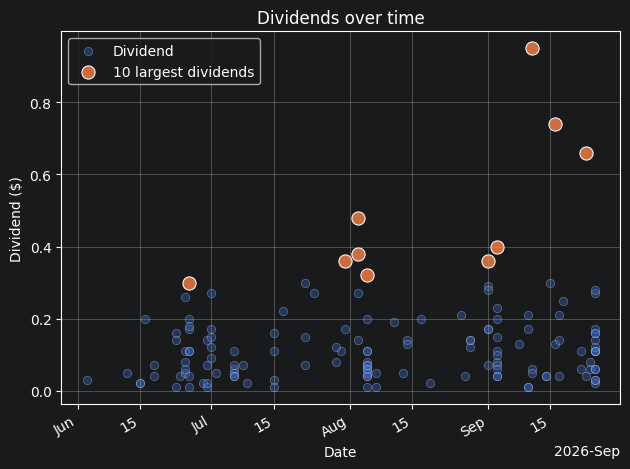

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
(div_data
 .groupby('asset_type')
 .agg(
    count=('amount', 'size'),
    total=('amount', 'sum'),
    mean=('amount', lambda x: x.mean().round(3)),
    # asset_price=('asset_price', lambda x: x.mean().round(3)),
    start=('date', 'min'),
    end=('date', 'max'),
    notes=('notes', lambda x: x.sort_values().tolist()[0]),
)
 .sort_values(['count', 'total', 'mean'], ascending=False)
 )

,count,total,mean,start,end,notes
asset_type,,,,,,
VMBS,4,0.40,0.100,2026-06-03,2026-09-03,$0.03 Dividend from Vanguard Mortgage-Backed S...
VGLT,3,0.78,0.260,2026-07-06,2026-09-03,$0.06 Dividend from Vanguard Long-Treasury ETF
JEPI,3,0.47,0.157,2026-07-06,2026-09-03,$0.07 Dividend from JPMorgan Equity Premium In...
BIV,3,0.26,0.087,2026-07-06,2026-09-03,$0.04 Dividend from Vanguard Intermediate Term...
BNDX,3,0.18,0.060,2026-07-06,2026-09-03,$0.05 Dividend from Vanguard Total Internation...
...,...,...,...,...,...,...
AVGO,1,0.01,0.010,2026-06-30,2026-06-30,$0.01 Dividend from Broadcom
COKE,1,0.01,0.010,2026-08-07,2026-08-07,$0.01 Dividend from Coca-Cola Consolidated
H,1,0.01,0.010,2026-09-10,2026-09-10,$0.01 Dividend from Hyatt Hotels Corporation


In [64]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
90,2026-08-17 13:30:23+00:00,-10.00,52.56,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
241,2026-07-02 13:30:00+00:00,-10.00,77.71,$10 Purchase of Vanguard Short Term Bond ETF,BSV
43,2026-09-03 04:00:00+00:00,0.06,NaN,$0.06 Dividend from Vanguard Short-Term Treasu...,VGSH
393,2026-06-16 15:43:17+00:00,-5.00,46.83,$5 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
377,2026-06-18 14:06:52+00:00,-5.00,50.45,$5 Purchase of Vanguard Tax-Exempt Bond ETF,VTEB
85,2026-08-27 17:22:57+00:00,-10.00,53.40,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
42,2026-09-03 04:00:00+00:00,0.07,NaN,$0.07 Dividend from Vanguard Short Term Bond ETF,BSV
676,2026-06-03 13:30:09+00:00,-10.00,220.70,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
264,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
115,2026-08-05 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Intermediate Term...,BIV


In [65]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VGLT    11
VONV    10
VMBS    10
VOO      8
VFH      7
VDE      6
BNDX     6
BIV      6
VCR      5
VNQ      5
VHT      5
VSS      5
VTEB     5
BND      5
VDC      4
VONG     4
BSV      4
VGSH     4
VCSH     3
VBR      3
VGT      2
Name: count, dtype: int64

In [66]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
90,2026-08-17 13:30:23+00:00,-10.00,52.56,VGLT,Vanguard Long-Treasury ETF
241,2026-07-02 13:30:00+00:00,-10.00,77.71,BSV,Vanguard Short Term Bond ETF
43,2026-09-03 04:00:00+00:00,0.06,NaN,VGSH,NaN
393,2026-06-16 15:43:17+00:00,-5.00,46.83,VMBS,Vanguard Mortgage-Backed Securities ETF
377,2026-06-18 14:06:52+00:00,-5.00,50.45,VTEB,Vanguard Tax-Exempt Bond ETF
85,2026-08-27 17:22:57+00:00,-10.00,53.40,VGLT,Vanguard Long-Treasury ETF
42,2026-09-03 04:00:00+00:00,0.07,NaN,BSV,NaN
676,2026-06-03 13:30:09+00:00,-10.00,220.70,VDC,Vanguard Consumer Staples Index Fund ETF
264,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
115,2026-08-05 04:00:00+00:00,0.11,NaN,BIV,NaN


In [67]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VGLT        Vanguard Long-Treasury ETF                     8
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           7
VMBS        Vanguard Mortgage-Backed Securities ETF        6
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BND         Vanguard Total Bond Market ETF                 3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
BNDX        Vanguard Total International Bond ETF          3
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGSH        Vanguard Short-Term Treasury ETF               2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 

In [68]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VGLT,VONV,VMBS,VOO,VFH,VDE,BNDX,BIV,VCR,VNQ,...,VSS,VTEB,BND,VDC,VONG,BSV,VGSH,VCSH,VBR,VGT
date,,,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-17 13:30:14+00:00,NaN,NaN,46.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:22+00:00,NaN,NaN,NaN,NaN,NaN,NaN,47.68,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:23+00:00,52.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
vanguard_trans_count

asset_type
VGLT    11
VONV    10
VMBS    10
VOO      8
VFH      7
VDE      6
BNDX     6
BIV      6
VCR      5
VNQ      5
VHT      5
VSS      5
VTEB     5
BND      5
VDC      4
VONG     4
BSV      4
VGSH     4
VCSH     3
VBR      3
VGT      2
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

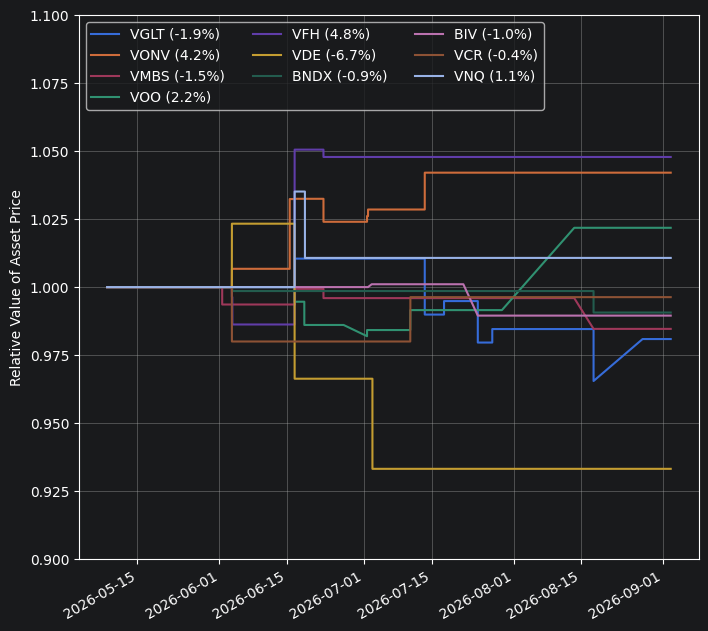

In [70]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [71]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
60,2026-08-28 22:38:29+00:00,10.0,Visa debit 3333,COMPLETE,Add Cash
78,2026-08-28 11:42:14+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
84,2026-08-27 17:23:15+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
134,2026-07-26 14:27:29+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
149,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
874,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
875,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
876,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
877,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [72]:
data_deposits['net_amount'].sum()

np.float64(6545.96)

In [73]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,74.0,88.458919,47.826235,1.0,62.5,100.0,100.0,200.0


In [74]:
data_deposits['net_amount'].cumsum()

60       10.00
78      110.00
84      210.00
134     310.00
149     410.00
        ...   
874    6440.96
875    6450.96
876    6500.96
877    6520.96
878    6545.96
Name: net_amount, Length: 74, dtype: float64

In [75]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
878,2026-05-26 19:39:34+00:00,25.00
877,2026-05-26 21:58:29+00:00,45.00
876,2026-05-27 00:43:01+00:00,95.00
875,2026-05-27 00:56:05+00:00,105.00
874,2026-05-27 00:56:27+00:00,205.00
...,...,...
149,2026-07-17 09:46:47+00:00,6235.96
134,2026-07-26 14:27:29+00:00,6335.96
84,2026-08-27 17:23:15+00:00,6435.96
78,2026-08-28 11:42:14+00:00,6535.96


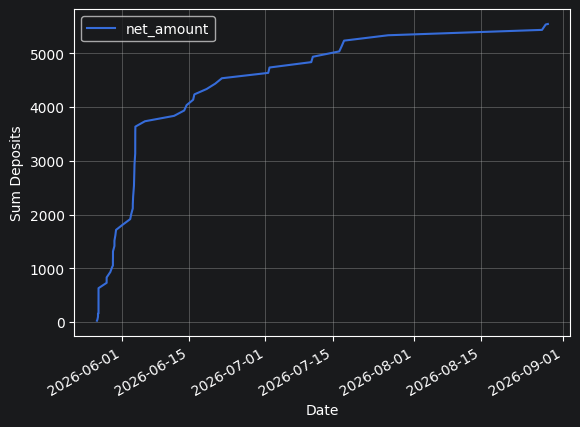

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [77]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.0
2026-05-26 21:58:29+00:00,0.0,20.0
2026-05-27 00:43:01+00:00,0.0,50.0
2026-05-27 00:56:05+00:00,0.0,10.0
2026-05-27 00:57:28+00:00,0.0,50.0
...,...,...
2026-07-17 09:46:47+00:00,100.0,0.0
2026-07-26 14:27:29+00:00,100.0,0.0
2026-08-27 17:23:15+00:00,100.0,0.0


In [78]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    5210.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64